# 04 - Store Segments

Rossmann has 1,115 stores and they do not all behave in the same way. Some live
on promotions, others sell steadily all year. This notebook asks a simple
question:

**Does it help to group the stores and treat the groups apart?**

There are three ways to answer it, and we test all three on the same four
windows:

- **A0**: one model for all stores, with no group information at all.
- **A**: one model for all stores, with the group given as a feature.
- **B**: one model for each group.

Before the test we have to build the groups, and we have to check that they are
worth having.

In [1]:
import sys
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.data_loader import DataLoader
from src.features import FeatureBuilder
from src.model import SalesModel, DEFAULT_PARAMS
from src.segments import StoreSegmenter, build_profiles, RESPONSE_COLS
from src.validation import RollingOriginSplit
from src.experiment import run_cv, compare

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

df = DataLoader(PROJECT_ROOT / "data").load()
folds = list(RollingOriginSplit(n_splits=4).split(df))
print("Rows:  ", f"{df.height:,}")
print("Stores:", df["Store"].n_unique())

Rows:   844,392
Stores: 1115


## A profile built from ratios, not from levels

The first decision is what to group the stores by.

The obvious answer is the level of sales, but the model already knows that. Our
strongest feature is `store_mean_sales`, so grouping stores by size would only
repeat something the model has.

What the model handles less well is *how* a store reacts. Two stores can both
sell 8,000 units a day and still be different businesses: one may gain 60
percent from a promotion, the other only 15 percent.

So every number in the profile is a ratio of the store against itself:

| Column | What it says |
|---|---|
| `promo_uplift` | sales on promotion days divided by sales on normal days |
| `school_uplift` | the same for school holidays |
| `weekend_ratio` | how much of the week sits at the weekend |
| `season_amp` | the best month divided by the worst month |
| `dec_lift` | how far December stands above the average month |
| `basket` | the money one shopper leaves behind |
| `momentum` | the last 90 days against the same days a year earlier |

In [2]:
profiles = build_profiles(folds[-1].train)

print(profiles.select(["Store", "mean_sales"] + RESPONSE_COLS).head())

print("\nHow far does each ratio follow the size of the store?")
size = profiles["mean_sales"].to_numpy()
for column in RESPONSE_COLS:
    r = np.corrcoef(size, profiles[column].to_numpy())[0, 1]
    print(f"  {column:<14} correlation with mean_sales: {r:+.3f}")

shape: (5, 9)
┌───────┬─────────────┬─────────────┬────────────┬───┬────────────┬──────────┬──────────┬──────────┐
│ Store ┆ mean_sales  ┆ promo_uplif ┆ school_upl ┆ … ┆ season_amp ┆ dec_lift ┆ basket   ┆ momentum │
│ ---   ┆ ---         ┆ t           ┆ ift        ┆   ┆ ---        ┆ ---      ┆ ---      ┆ ---      │
│ i64   ┆ f64         ┆ ---         ┆ ---        ┆   ┆ f64        ┆ f64      ┆ f64      ┆ f64      │
│       ┆             ┆ f64         ┆ f64        ┆   ┆            ┆          ┆          ┆          │
╞═══════╪═════════════╪═════════════╪════════════╪═══╪════════════╪══════════╪══════════╪══════════╡
│ 1     ┆ 4776.826846 ┆ 1.222469    ┆ 1.001409   ┆ … ┆ 1.480462   ┆ 1.305519 ┆ 8.42843  ┆ 0.969632 │
│ 2     ┆ 4954.342246 ┆ 1.626475    ┆ 1.091859   ┆ … ┆ 1.338813   ┆ 1.248766 ┆ 8.495676 ┆ 1.025034 │
│ 3     ┆ 6947.705249 ┆ 1.648104    ┆ 1.069911   ┆ … ┆ 1.36705    ┆ 1.246049 ┆ 9.226733 ┆ 1.068809 │
│ 4     ┆ 9621.410428 ┆ 1.187122    ┆ 1.06506    ┆ … ┆ 1.30923    ┆ 1.228878 

This is the number that decides whether the whole idea is worth anything. Every
correlation sits between -0.21 and +0.16, which is close to zero.

The behaviour of a store is therefore almost independent of its size. The
profile carries information that `store_mean_sales` does not have, and grouping
on it is not a repetition of what the model already knows.

## From micro cells to segments

We build the groups in two steps, and the reason is the shape of the data.

First we cut three of the numbers into quantile bins: the size, the promotion
uplift and the strength of the season. That gives a grid of small cells. Cells
with fewer than 15 stores are joined to the cell nearest to them, because a
cell of three stores is noise.

Then we describe each cell by its average behaviour and join the cells that
behave alike, until four segments are left.

The whole thing is fitted on the training rows of the fold only. Every number
in the profile comes from the sales, so fitting it once on the full table would
let the window we score leak into the groups.

In [3]:
segmenter = StoreSegmenter(n_segments=4).fit(folds[-1].train)

print("Stores held back for a short history:", segmenter.n_short_history_)
print()
print(segmenter.summary_.select(["segment", "stores", "sales_share", "store_share", "lift"]))
print()
with pl.Config(tbl_cols=12, tbl_width_chars=200):
    print(segmenter.describe())

Stores held back for a short history: 0

shape: (4, 5)
┌─────────┬────────┬─────────────┬─────────────┬──────────┐
│ segment ┆ stores ┆ sales_share ┆ store_share ┆ lift     │
│ ---     ┆ ---    ┆ ---         ┆ ---         ┆ ---      │
│ i32     ┆ u32    ┆ f64         ┆ f64         ┆ f64      │
╞═════════╪════════╪═════════════╪═════════════╪══════════╡
│ 1       ┆ 127    ┆ 0.108437    ┆ 0.113901    ┆ 0.952027 │
│ 2       ┆ 245    ┆ 0.207997    ┆ 0.219731    ┆ 0.946598 │
│ 3       ┆ 484    ┆ 0.425039    ┆ 0.434081    ┆ 0.979171 │
│ 4       ┆ 259    ┆ 0.258527    ┆ 0.232287    ┆ 1.112963 │
└─────────┴────────┴─────────────┴─────────────┴──────────┘

shape: (4, 10)
┌─────────┬────────┬────────────┬──────────────┬───────────────┬───────────────┬────────────┬──────────┬────────┬──────────┐
│ segment ┆ stores ┆ mean_sales ┆ promo_uplift ┆ school_uplift ┆ weekend_ratio ┆ season_amp ┆ dec_lift ┆ basket ┆ momentum │
│ ---     ┆ ---    ┆ ---        ┆ ---          ┆ ---           ┆ ---           

The four segments have clear characters.

- **Segment 1** (127 stores) reacts most strongly to promotions, uplift 1.64,
  and has the sharpest season. Its weekend is the quietest of all, 0.75.
- **Segment 2** (245 stores) also lives on promotions, uplift 1.60, but its
  year is much flatter.
- **Segment 3** (484 stores) is the opposite: promotions help far less, 1.32,
  the weekend is almost as strong as the week, and the basket is the largest.
- **Segment 4** (259 stores) holds the largest stores, has the flattest year
  and the smallest basket.

Look at the `lift` column: it runs from 0.95 to 1.11, so all four segments carry
about as much sales as their number of stores would suggest.

That is worth a note. Lift is the usual way to order value segments, where one
group really does carry the money. Our groups are built from behaviour, not from
value, so lift cannot separate them. We use it to describe the segments, but we
order them by the promotion uplift, which does separate them clearly.

## Check 1: are the segments only StoreType in disguise?

The model already has `StoreType` as a feature. If our segments simply repeat
it, they add nothing and we should stop here.

In [4]:
store_type = folds[-1].train.unique(subset="Store").select(["Store", "StoreType"])
crosstab = (
    segmenter.assignment_.join(store_type, on="Store")
    .group_by(["segment", "StoreType"]).len()
    .pivot(on="StoreType", index="segment", values="len")
    .fill_null(0).sort("segment")
)
print(crosstab)

shape: (4, 5)
┌─────────┬─────┬─────┬─────┬─────┐
│ segment ┆ a   ┆ b   ┆ c   ┆ d   │
│ ---     ┆ --- ┆ --- ┆ --- ┆ --- │
│ i32     ┆ u32 ┆ u32 ┆ u32 ┆ u32 │
╞═════════╪═════╪═════╪═════╪═════╡
│ 1       ┆ 86  ┆ 0   ┆ 13  ┆ 28  │
│ 2       ┆ 169 ┆ 3   ┆ 18  ┆ 55  │
│ 3       ┆ 184 ┆ 3   ┆ 96  ┆ 201 │
│ 4       ┆ 163 ┆ 11  ┆ 21  ┆ 64  │
└─────────┴─────┴─────┴─────┴─────┘


They do not. Every segment holds stores of every type, and the mix changes from
segment to segment: type `d` is 201 of the 484 stores in segment 3 but only 28
of the 127 in segment 1.

The segments cut across `StoreType` instead of following it, so they carry
information the model did not have.

## Check 2: do the segments stay the same?

A segment is only useful if it describes the store and not the accident of the
window we fitted on. We fit the segmenter on each of the four folds and compare
the results.

We use the Adjusted Rand Index. It compares two groupings without caring about
the labels, so it is not disturbed when group 2 of one fold is called group 3 in
another. A value of 1.0 means the same split, and 0.0 means no more agreement
than chance.

In [5]:
labels = {}
for fold in folds:
    fitted = StoreSegmenter(n_segments=4).fit(fold.train)
    labels[fold.index] = fitted.assignment_.sort("Store")["segment"].to_numpy()

print("Agreement between the folds (Adjusted Rand Index)")
for i in sorted(labels):
    for j in sorted(labels):
        if i < j:
            print(f"  fold {i} and fold {j}: {adjusted_rand_score(labels[i], labels[j]):.3f}")

same = sum(1 for k in range(len(labels[1]))
           if len({labels[i][k] for i in labels}) == 1)
print(f"\nStores with the same label in all four folds: {same} of {len(labels[1])}"
      f" ({100 * same / len(labels[1]):.0f} percent)")

Agreement between the folds (Adjusted Rand Index)
  fold 1 and fold 2: 0.933
  fold 1 and fold 3: 0.922
  fold 1 and fold 4: 0.292
  fold 2 and fold 3: 0.970
  fold 2 and fold 4: 0.301
  fold 3 and fold 4: 0.307

Stores with the same label in all four folds: 728 of 1115 (65 percent)


This is a mixed result and we should say so plainly.

Folds 1, 2 and 3 agree almost completely, with an index between 0.92 and 0.97.
Fold 4 draws a different picture, and its agreement with the others falls to
about 0.30.

Fold 4 is the fold with the longest training period, so its profiles are built
on more history. Two of the ratios depend on the calendar in a direct way: the
momentum compares the last 90 days with the same days a year earlier, and the
December lift needs a December. Moving the end of the training window by a few
months changes those two numbers, and the grouping moves with them.

So the segments are stable over most of our windows but not over all of them.
They are a good working tool, not a fixed property of a store. Because we fit
the segmenter again inside every fold, each fold still uses one consistent set
of groups, and the test below stays fair.

## The experiment

Now the real question. We run the three approaches over the four windows.

One thing we learned in notebook 03 is that this model moves a little from run
to run: it draws 80 percent of the columns for each tree, so the random seed
changes the score. A difference of 0.002 told us nothing there. To avoid
reading noise as a result, we run every approach with **three seeds** and look
at the average and at the spread.

This cell takes several minutes.

In [6]:
SEGMENTS = [1, 2, 3, 4]
SEEDS = [42, 7, 2024]


def params_with(seed):
    p = dict(DEFAULT_PARAMS)
    p["seed"] = seed
    return p


def global_model(seed):
    """A0: one model for every store."""
    def fit_predict(train, valid):
        builder = FeatureBuilder().fit(train)
        tr, va = builder.transform(train), builder.transform(valid)
        model = SalesModel(params=params_with(seed)).fit(tr, builder.feature_names_)
        return va.with_columns(pl.Series("prediction", model.predict(va)))
    return fit_predict


def global_with_segment(seed):
    """A: one model, with the segment handed over as a feature."""
    def fit_predict(train, valid):
        builder = FeatureBuilder().fit(train)
        segmenter = StoreSegmenter(n_segments=4).fit(train)
        one_hot = [(pl.col("segment") == s).cast(pl.Int8).alias(f"segment_{s}")
                   for s in SEGMENTS]
        tr = segmenter.transform(builder.transform(train)).with_columns(one_hot)
        va = segmenter.transform(builder.transform(valid)).with_columns(one_hot)
        features = list(builder.feature_names_) + [f"segment_{s}" for s in SEGMENTS]
        model = SalesModel(params=params_with(seed)).fit(tr, features)
        return va.with_columns(pl.Series("prediction", model.predict(va)))
    return fit_predict


def model_per_segment(seed):
    """B: one model for each segment."""
    def fit_predict(train, valid):
        builder = FeatureBuilder().fit(train)
        segmenter = StoreSegmenter(n_segments=4).fit(train)
        tr = segmenter.transform(builder.transform(train))
        va = segmenter.transform(builder.transform(valid))
        parts = []
        for s in SEGMENTS:
            tr_s = tr.filter(pl.col("segment") == s)
            va_s = va.filter(pl.col("segment") == s)
            if va_s.height == 0:
                continue
            model = SalesModel(params=params_with(seed)).fit(tr_s, builder.feature_names_)
            parts.append(va_s.with_columns(pl.Series("prediction", model.predict(va_s))))
        return pl.concat(parts)
    return fit_predict

In [7]:
arms = {
    "A0 no segment": global_model,
    "A  segment as feature": global_with_segment,
    "B  model per segment": model_per_segment,
}

results = {}
for name, factory in arms.items():
    per_seed = []
    for seed in SEEDS:
        scores, _ = run_cv(df, factory(seed))
        per_seed.append(scores["rmspe"].to_numpy())
    results[name] = np.vstack(per_seed)      # three seeds by four folds
    means = results[name].mean(axis=1)
    print(f"{name:<24} seeds: " + "  ".join(f"{m:.4f}" for m in means)
          + f"   mean={means.mean():.4f}  spread={means.std():.4f}")

A0 no segment            seeds: 0.1472  0.1505  0.1513   mean=0.1497  spread=0.0018


A  segment as feature    seeds: 0.1490  0.1490  0.1492   mean=0.1491  spread=0.0001


B  model per segment     seeds: 0.1451  0.1454  0.1449   mean=0.1451  spread=0.0002


In [8]:
summary = pl.DataFrame({
    "fold": ["1", "2", "3", "4", "mean"],
    **{name: [*matrix.mean(axis=0), matrix.mean()] for name, matrix in results.items()},
})
print(summary)

shape: (5, 4)
┌──────┬───────────────┬───────────────────────┬──────────────────────┐
│ fold ┆ A0 no segment ┆ A  segment as feature ┆ B  model per segment │
│ ---  ┆ ---           ┆ ---                   ┆ ---                  │
│ str  ┆ f64           ┆ f64                   ┆ f64                  │
╞══════╪═══════════════╪═══════════════════════╪══════════════════════╡
│ 1    ┆ 0.179514      ┆ 0.178486              ┆ 0.175908             │
│ 2    ┆ 0.152327      ┆ 0.151078              ┆ 0.144104             │
│ 3    ┆ 0.130525      ┆ 0.12845               ┆ 0.125951             │
│ 4    ┆ 0.13639       ┆ 0.138212              ┆ 0.134508             │
│ mean ┆ 0.149689      ┆ 0.149057              ┆ 0.145118             │
└──────┴───────────────┴───────────────────────┴──────────────────────┘


The order is clear, and it is not the one we expected.

**B wins.** One model per segment scores **0.1451**, against **0.1497** for the
single global model. That is a gain of 0.0046, which is more than twice the
noise we measured in notebook 03, and B is ahead on all four windows.

**A does almost nothing.** Handing the segment to one model as a feature gives
0.1491, only 0.0006 better than not having it at all. That sits inside the
noise.

There is a second difference that is easy to miss. Look at the spread over the
seeds: the global model moves by 0.0018 from seed to seed, while the segmented
one moves by 0.0002. Splitting the data does not only give a better score, it
gives a score we can trust. Each smaller model sees stores that behave alike, so
the random draw of rows and columns matters much less.

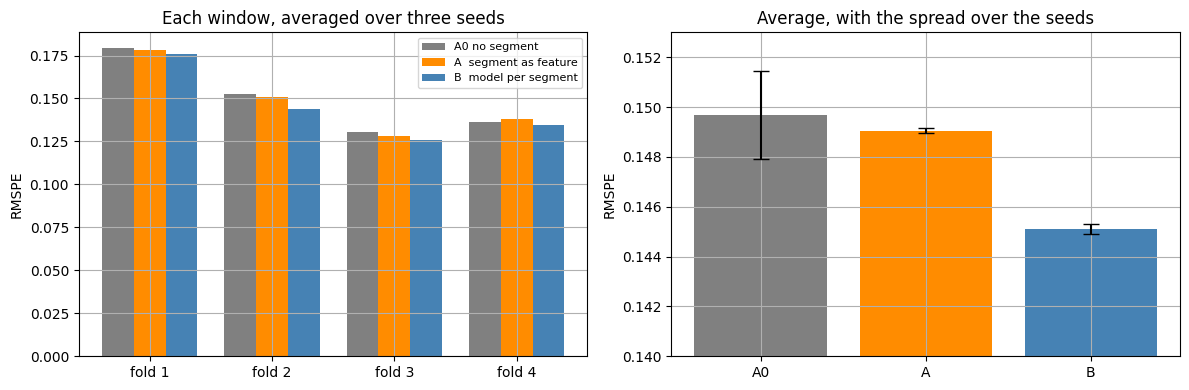

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(1, 5)
width = 0.26
colors = ["gray", "darkorange", "steelblue"]
for i, (name, matrix) in enumerate(results.items()):
    axes[0].bar(x + (i - 1) * width, matrix.mean(axis=0), width, label=name, color=colors[i])
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"fold {i}" for i in x])
axes[0].set_ylabel("RMSPE")
axes[0].set_title("Each window, averaged over three seeds")
axes[0].legend(fontsize=8)

names = list(results)
means = [m.mean(axis=1).mean() for m in results.values()]
spreads = [m.mean(axis=1).std() for m in results.values()]
axes[1].bar(range(3), means, yerr=spreads, capsize=6, color=colors)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(["A0", "A", "B"])
axes[1].set_ylabel("RMSPE")
axes[1].set_ylim(0.14, 0.153)
axes[1].set_title("Average, with the spread over the seeds")

plt.tight_layout()
plt.show()

## Why we expected the opposite

Before the test, the argument against splitting looked strong.

A tree can split on the segment at its root, and everything below that split is
already a model for that segment. So one model *can* do what four models do,
and it keeps the option of sharing whenever sharing helps. On top of that, the
training data holds only two Decembers, and cutting it into four parts leaves
each smaller model with less of the season.

The measurement says otherwise, and there are two reasons why.

First, the tree can only split on the segment if the split is worth more than
the other splits at that point. With 24 features it usually is not, and the
model spreads its effort instead of specialising. Four separate models do not
have that choice, so the specialisation happens whether it pays at the root or
not.

Second, the cost we feared does not appear in these windows. All four of them
lie between February and July, so none of them tests what the model knows about
December. The loss from cutting the season into four is real, but our folds
cannot see it.

That second point is a warning as much as an explanation. The competition
window is August and September, which is also outside the season, so the result
should carry over. A model that had to forecast December might behave
differently.

## Key findings

1. **One model per segment wins.** 0.1451 against 0.1497 for a single global
   model, ahead on all four windows, and the gap is more than twice the noise.
2. **Giving the segment as a feature does not work.** 0.1491, which is inside
   the noise. If the groups are to help, they have to change the structure of
   the model and not only the feature list.
3. **The segmented model is also steadier.** Its score moves by 0.0002 between
   seeds, against 0.0018 for the global model.
4. The profile is built from ratios, so the groups are almost independent of
   store size. Every correlation with `store_mean_sales` sits between -0.21 and
   +0.16.
5. The segments are not a copy of `StoreType`. They cut across it.
6. **The segments are not fully stable.** Three of the four folds agree closely,
   but the fourth draws a different split. This is a working tool, not a fixed
   property of a store.
7. Lift describes the segments but cannot order them, because behaviour groups
   all carry about the same sales per store. We order them by the promotion
   uplift instead.